# FRC District Event Planner

Goal: pick which two regular-season district events to preference for a season so a
team can qualify to the district championship without back-to-back events.

Configure `TEAM`, `TARGET_YEAR`, `DISTRICT_ABBREVIATION`, and optionally
`PREFERRED_EVENT_CODES` in the next cell -- everything downstream follows from those,
so this notebook works for any FRC team, in any district, in any season.

Assumptions:
- If `TARGET_YEAR`'s official schedule/rosters aren't published yet, set `DATA_YEAR`
  to the most recent season with real data as a stand-in for both the event calendar
  and field strength (the teams that attended each event, using their `DATA_YEAR`
  EPA). Once `TARGET_YEAR` is published, set `DATA_YEAR = TARGET_YEAR` and re-run.
- "Best" events = weaker average field EPA, since a weaker field means more
  scoring/RP opportunities and better odds of banking district points toward champs
  qualification.
- Events closer together than `MIN_WEEK_GAP` weeks are excluded even if they'd
  otherwise score well, since there's no time between them to iterate on the robot.
- `PREFERRED_EVENT_CODES` is an optional allowlist of TBA event codes, for teams that
  only want to consider a sub-region of their district (e.g. Southern California
  only, to avoid Northern California travel). Leave it empty (`set()`) to consider
  every event in the district.

Data sources: event schedule + team rosters come from The Blue Alliance (TBA); EPA
ratings come from Statbotics. As a cross-check, field strength is also compared using
TBA's own OPR rating further down.


In [26]:
import os
import getpass
import itertools
from datetime import date
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import statbotics

# --- Configure for your team / season / district ---

TEAM = 2429

# The season you're planning for.
TARGET_YEAR = 2027

# The season whose actual schedule/rosters/EPA are used as data. Set this equal
# to TARGET_YEAR once that season's real events are published; until then, use
# the most recent season with real data as a stand-in.
DATA_YEAR = 2026

# TBA district abbreviation for the district's TARGET_YEAR season, e.g. "ca"
# (California), "fim" (Michigan), "ne" (New England), "pnw" (Pacific Northwest),
# "fma" (Mid-Atlantic), "fnc" (North Carolina), "fsc" (South Carolina), "fch"
# (Chesapeake), "fin" (Indiana), "fit" (In Texas), "win" (Wisconsin), "ont"
# (Ontario), "pch" (Peachtree), "isr" (Israel). If unsure, check GET
# /districts/{year} for the full list of abbreviations for that season.
DISTRICT_ABBREVIATION = "ca"

# Optional allowlist of TBA event codes, for teams that only want to consider a
# sub-region of their district (e.g. Southern California only, to avoid
# Northern California travel). Leave empty (set()) to consider every event in
# the district.
PREFERRED_EVENT_CODES = {
    "capoh", "caven", "calas", "casnd",
    "cagle", "casgv", "caasv", "caoec",
}

# Minimum number of weeks required between two preferenced events.
MIN_WEEK_GAP = 2

TBA_BASE_URL = "https://www.thebluealliance.com/api/v3"

# Key lookup order: env var, then a local key file (gitignored, never committed),
# then fall back to an interactive prompt so this notebook still works standalone.
TBA_KEY_FILE = Path(".tba_auth_key")

if os.environ.get("TBA_AUTH_KEY"):
    TBA_AUTH_KEY = os.environ["TBA_AUTH_KEY"]
elif TBA_KEY_FILE.is_file():
    TBA_AUTH_KEY = TBA_KEY_FILE.read_text(encoding="utf-8").strip()
else:
    TBA_AUTH_KEY = getpass.getpass(
        "TBA X-TBA-Auth-Key (kept in memory only, not saved to this notebook): "
    )

sb = statbotics.Statbotics()

In [27]:
def tba_get(path):
    resp = requests.get(
        TBA_BASE_URL + path,
        headers={
            "X-TBA-Auth-Key": TBA_AUTH_KEY,
            "accept": "application/json",
            "User-Agent": f"{TEAM}-event-planner",
        },
    )
    resp.raise_for_status()
    return resp.json()

In [28]:
# Only consider real in-season events -- exclude offseason (99), preseason
# (100), and unlabeled (-1) events. Their results aren't useful for district
# event preferencing.
OFFICIAL_EVENT_TYPES = {0, 1, 2, 3, 4, 5, 6}

district_key = f"{DATA_YEAR}{DISTRICT_ABBREVIATION}"
district_events = [
    e for e in tba_get(f"/district/{district_key}/events/simple")
    if e.get("event_type") in OFFICIAL_EVENT_TYPES
    and (not PREFERRED_EVENT_CODES or e.get("event_code") in PREFERRED_EVENT_CODES)
]

print(
    f"Found {len(district_events)} events in district {district_key}"
    f"{' (filtered by PREFERRED_EVENT_CODES)' if PREFERRED_EVENT_CODES else ''}:"
)
for e in sorted(district_events, key=lambda e: e["start_date"]):
    print(
        f"  {e['start_date']}  {e['name']:<45} "
        f"code={e.get('event_code'):<8} key={e['key']:<12} type={e.get('event_type')}"
    )

Found 8 events in district 2026ca (filtered by PREFERRED_EVENT_CODES):
  2026-03-06  CA District Hueneme Port Event                code=capoh    key=2026capoh    type=1
  2026-03-13  CA District Ventura County Event              code=caven    key=2026caven    type=1
  2026-03-20  CA District Los Angeles Event                 code=calas    key=2026calas    type=1
  2026-03-20  CA District San Diego Event presented by Qualcomm code=casnd    key=2026casnd    type=1
  2026-03-27  CA District Glendale Event                    code=cagle    key=2026cagle    type=1
  2026-03-27  CA District San Gabriel Valley Event          code=casgv    key=2026casgv    type=1
  2026-04-02  CA District Aerospace Valley Event            code=caasv    key=2026caasv    type=1
  2026-04-02  CA District Orange County Event               code=caoec    key=2026caoec    type=1


In [29]:
# TBA's "week" field can come back None depending on season/district, so
# instead we group events by the ISO calendar week of their start_date -- FRC
# events run Thursday-Saturday, so all matches in the same real-world week
# share an ISO (year, week) key.
def event_week_key(event):
    d = date.fromisoformat(event["start_date"])
    return d.isocalendar()[:2]

qual_events = sorted(
    (e for e in district_events if e.get("event_type") == 1),
    key=lambda e: e["start_date"],
)
champ_events = [e for e in district_events if e.get("event_type") in (2, 5)]

week_keys = sorted({event_week_key(e) for e in qual_events})
week_number = {wk: i + 1 for i, wk in enumerate(week_keys)}
for e in qual_events:
    e["week_number"] = week_number[event_week_key(e)]

print("Selected events:")
for e in qual_events:
    print(f"  Week {e['week_number']}: {e['name']} ({e['key']}) - {e['start_date']}")

print()
if champ_events:
    for e in champ_events:
        print(f"Championship: {e['name']} ({e['key']}) - {e['start_date']}")
else:
    print(f"No championship-type event found among {district_key} events considered.")

Selected events:
  Week 1: CA District Hueneme Port Event (2026capoh) - 2026-03-06
  Week 2: CA District Ventura County Event (2026caven) - 2026-03-13
  Week 3: CA District Los Angeles Event (2026calas) - 2026-03-20
  Week 3: CA District San Diego Event presented by Qualcomm (2026casnd) - 2026-03-20
  Week 4: CA District Glendale Event (2026cagle) - 2026-03-27
  Week 4: CA District San Gabriel Valley Event (2026casgv) - 2026-03-27
  Week 5: CA District Aerospace Valley Event (2026caasv) - 2026-04-02
  Week 5: CA District Orange County Event (2026caoec) - 2026-04-02

No championship-type event found among 2026ca events considered.


## Field strength per event

For each qualifying event, pull the attending teams from TBA, look up each team's
`DATA_YEAR` EPA from Statbotics, and summarize the field with the mean EPA (typical
opponent) and the top-8 EPA (how tough the alliance captains will be).


In [30]:
_epa_cache = {}

def get_team_epa(team_number, year):
    key = (team_number, year)
    if key not in _epa_cache:
        try:
            data = sb.get_team_year(team_number, year)
            _epa_cache[key] = data["epa"]["breakdown"]["total_points"]
        except Exception:
            _epa_cache[key] = None
    return _epa_cache[key]

own_epa = get_team_epa(TEAM, DATA_YEAR)
print(f"Team {TEAM} {DATA_YEAR} EPA: {own_epa}")

Team 2429 2026 EPA: 94.55


In [31]:
rows = []
for e in qual_events:
    teams = tba_get(f"/event/{e['key']}/teams/simple")
    team_numbers = [t["team_number"] for t in teams]

    epas = [
        epa for epa in (get_team_epa(t, DATA_YEAR) for t in team_numbers)
        if epa is not None
    ]
    epas_sorted = sorted(epas, reverse=True)

    rows.append({
        "week": e["week_number"],
        "event_key": e["key"],
        "name": e["name"],
        "city": e.get("city"),
        "start_date": e["start_date"],
        "num_teams": len(team_numbers),
        "num_epa_found": len(epas),
        "epa_mean": np.mean(epas) if epas else np.nan,
        "epa_top8": np.mean(epas_sorted[:8]) if len(epas_sorted) >= 8 else np.nan,
        "epa_max": max(epas) if epas else np.nan,
        "team_here": TEAM in team_numbers,
    })

df_events = pd.DataFrame(rows).sort_values("week").reset_index(drop=True)
df_events

,week,event_key,name,city,start_date,num_teams,num_epa_found,epa_mean,epa_top8,epa_max,team_here
0,1,2026capoh,CA District Hueneme Port Event,Port Hueneme,2026-03-06,42,42,57.101190,139.15125,202.25,True
1,2,2026caven,CA District Ventura County Event,Ventura,2026-03-13,36,36,81.423333,205.20000,356.94,False
2,3,2026calas,CA District Los Angeles Event,El Segundo,2026-03-20,42,42,62.572143,155.27500,211.99,False
3,3,2026casnd,CA District San Diego Event presented by Qualcomm,San Diego,2026-03-20,40,40,51.130000,129.28375,191.08,False
4,4,2026cagle,CA District Glendale Event,Glendale,2026-03-27,37,37,74.115946,173.92000,202.25,True
5,4,2026casgv,CA District San Gabriel Valley Event,Rosemead,2026-03-27,29,29,57.471379,128.17500,193.41,False
6,5,2026caasv,CA District Aerospace Valley Event,Lancaster,2026-04-02,34,34,67.694706,149.95875,169.15,False
7,5,2026caoec,CA District Orange County Event,Mission Viejo,2026-04-02,37,37,65.375405,168.20250,356.94,False


## Choosing a non-back-to-back pair of events

Enumerate every pair of events at least `MIN_WEEK_GAP` weeks apart, and rank pairs by
their combined average field EPA (lower combined EPA = easier schedule = better shot
at banking qualifying points without back-to-back weekends).


In [32]:
candidates = df_events.dropna(subset=["epa_mean"]).to_dict("records")

pairs = []
for a, b in itertools.combinations(candidates, 2):
    if abs(a["week"] - b["week"]) < MIN_WEEK_GAP:
        continue  # too close together - not enough time to iterate, skip
    pairs.append({
        "week_a": a["week"], "event_a": a["name"], "event_key_a": a["event_key"],
        "week_b": b["week"], "event_b": b["name"], "event_key_b": b["event_key"],
        "combined_epa_mean": (a["epa_mean"] + b["epa_mean"]) / 2,
        "combined_epa_top8": np.nanmean([a["epa_top8"], b["epa_top8"]]),
    })

df_pairs = pd.DataFrame(
    pairs,
    columns=["week_a", "event_a", "event_key_a", "week_b", "event_b", "event_key_b",
             "combined_epa_mean", "combined_epa_top8"],
)
if not df_pairs.empty:
    df_pairs = df_pairs.sort_values("combined_epa_mean").reset_index(drop=True)
else:
    print(
        f"No valid pairs at least {MIN_WEEK_GAP} week(s) apart found among "
        f"{len(candidates)} candidate event(s) with EPA data. Check the 'Selected "
        "events' list printed above and whether those events have epa_mean data "
        "in df_events."
    )
df_pairs.head(10)

,week_a,event_a,event_key_a,week_b,event_b,event_key_b,combined_epa_mean,combined_epa_top8
0,1,CA District Hueneme Port Event,2026capoh,3,CA District San Diego Event presented by Qualcomm,2026casnd,54.115595,134.217500
1,1,CA District Hueneme Port Event,2026capoh,4,CA District San Gabriel Valley Event,2026casgv,57.286285,133.663125
2,3,CA District San Diego Event presented by Qualcomm,2026casnd,5,CA District Orange County Event,2026caoec,58.252703,148.743125
3,3,CA District San Diego Event presented by Qualcomm,2026casnd,5,CA District Aerospace Valley Event,2026caasv,59.412353,139.621250
4,1,CA District Hueneme Port Event,2026capoh,3,CA District Los Angeles Event,2026calas,59.836667,147.213125
5,1,CA District Hueneme Port Event,2026capoh,5,CA District Orange County Event,2026caoec,61.238298,153.676875
6,1,CA District Hueneme Port Event,2026capoh,5,CA District Aerospace Valley Event,2026caasv,62.397948,144.555000
7,3,CA District Los Angeles Event,2026calas,5,CA District Orange County Event,2026caoec,63.973774,161.738750
8,3,CA District Los Angeles Event,2026calas,5,CA District Aerospace Valley Event,2026caasv,65.133424,152.616875
9,1,CA District Hueneme Port Event,2026capoh,4,CA District Glendale Event,2026cagle,65.608568,156.535625


In [33]:
if df_pairs.empty:
    print("No candidate pair to recommend -- see note above.")
else:
    best = df_pairs.iloc[0]
    print(
        f"Recommended pair: Week {best['week_a']:.0f} ({best['event_a']}) "
        f"+ Week {best['week_b']:.0f} ({best['event_b']})\n"
        f"Combined avg field EPA: {best['combined_epa_mean']:.1f} "
        f"(combined top-8 EPA: {best['combined_epa_top8']:.1f})"
    )

Recommended pair: Week 1 (CA District Hueneme Port Event) + Week 3 (CA District San Diego Event presented by Qualcomm)
Combined avg field EPA: 54.1 (combined top-8 EPA: 134.2)


In [34]:
def plot_field_strength_by_week(df, value_col, recommended_keys, ylabel, title):
    """Grouped bar chart of `value_col` per event, dodged within each week's
    cluster (some weeks can have multiple events) and colored red for the
    events in `recommended_keys`.
    """
    plt.figure(figsize=(10, 5))
    group_width = 0.8
    for week, group in df.groupby("week"):
        group = group.sort_values("event_key")
        n = len(group)
        bar_width = group_width / n
        offsets = (np.arange(n) - (n - 1) / 2) * bar_width
        for offset, (_, row) in zip(offsets, group.iterrows()):
            x = week + offset
            color = "tab:red" if row["event_key"] in recommended_keys else "tab:gray"
            plt.bar(x, row[value_col], width=bar_width * 0.9, color=color)
            plt.annotate(
                row["event_key"][-5:], xy=(x, row[value_col]), xytext=(0, 5),
                textcoords="offset points", ha="center", fontsize=10, rotation=20,
            )
    plt.xlabel("Week")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(sorted(df["week"].unique()))
    plt.tight_layout()
    plt.show()

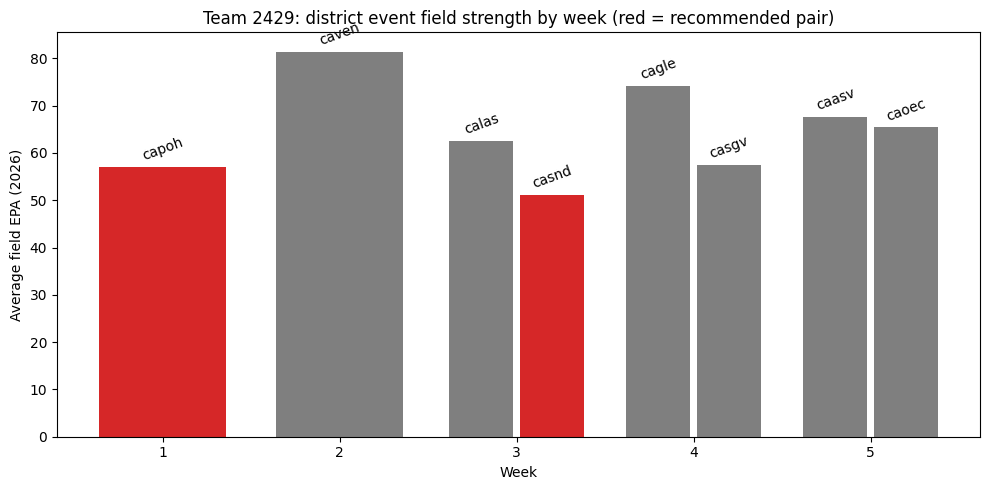

In [35]:
if df_pairs.empty:
    print("Skipping chart -- no recommended pair (see note above).")
else:
    # Highlight the specific recommended events by key, not just their week --
    # a week can have multiple events, and only one of them may be recommended.
    recommended_keys = {best["event_key_a"], best["event_key_b"]}
    plot_field_strength_by_week(
        df_events, "epa_mean", recommended_keys,
        ylabel=f"Average field EPA ({DATA_YEAR})",
        title=f"Team {TEAM}: district event field strength by week (red = recommended pair)",
    )

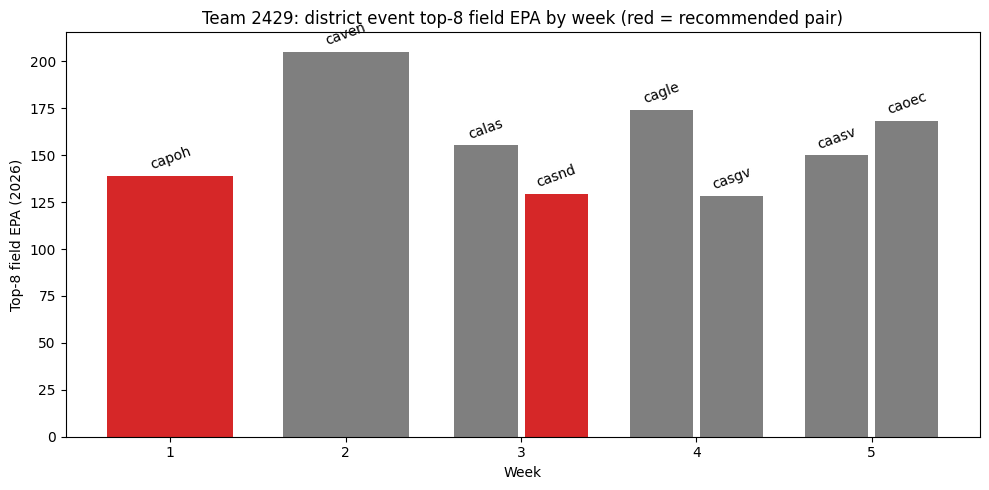

In [36]:
if df_pairs.empty:
    print("Skipping chart -- no recommended pair (see note above).")
else:
    plot_field_strength_by_week(
        df_events, "epa_top8", recommended_keys,
        ylabel=f"Top-8 field EPA ({DATA_YEAR})",
        title=f"Team {TEAM}: district event top-8 field EPA by week (red = recommended pair)",
    )

## Field strength per event (OPR -- The Blue Alliance)

Same comparison as above, but using The Blue Alliance's OPR instead of Statbotics EPA.
Statbotics EPA is a season-level rating that exists even before a team plays a match;
TBA's OPR is only computed from actual match results at a specific event, so there's
no direct "OPR for team X in year Y" the way there is for EPA. As a proxy, we use each
team's OPR from the **most recent official `DATA_YEAR` event they actually played**
(via TBA's `/event/{key}/oprs`). This is noisier than EPA -- a single event's OPR
depends heavily on alliance partners and opponents -- so treat it as a sanity check on
the EPA-based recommendation above, not a replacement for it.


In [37]:
_event_oprs_cache = {}

def get_event_oprs(event_key):
    if event_key not in _event_oprs_cache:
        try:
            data = tba_get(f"/event/{event_key}/oprs")
            _event_oprs_cache[event_key] = (data or {}).get("oprs") or {}
        except Exception:
            _event_oprs_cache[event_key] = {}
    return _event_oprs_cache[event_key]

_opr_cache = {}

def get_team_opr(team_number, year):
    key = (team_number, year)
    if key in _opr_cache:
        return _opr_cache[key]

    team_key = f"frc{team_number}"
    try:
        events = [
            e for e in tba_get(f"/team/{team_key}/events/{year}/simple")
            if e.get("event_type") in OFFICIAL_EVENT_TYPES
        ]
    except Exception:
        events = []
    events.sort(key=lambda e: e["start_date"])

    opr = None
    for e in reversed(events):  # walk backward: most recent event with a published OPR
        oprs = get_event_oprs(e["key"])
        if team_key in oprs:
            opr = oprs[team_key]
            break

    _opr_cache[key] = opr
    return opr

own_opr = get_team_opr(TEAM, DATA_YEAR)
print(f"Team {TEAM} {DATA_YEAR} OPR (most recent event played): {own_opr}")

Team 2429 2026 OPR (most recent event played): 68.02000626872916


In [38]:
rows_opr = []
for e in qual_events:
    teams = tba_get(f"/event/{e['key']}/teams/simple")
    team_numbers = [t["team_number"] for t in teams]

    oprs = [
        opr for opr in (get_team_opr(t, DATA_YEAR) for t in team_numbers)
        if opr is not None
    ]
    oprs_sorted = sorted(oprs, reverse=True)

    rows_opr.append({
        "week": e["week_number"],
        "event_key": e["key"],
        "name": e["name"],
        "city": e.get("city"),
        "start_date": e["start_date"],
        "num_teams": len(team_numbers),
        "num_opr_found": len(oprs),
        "opr_mean": np.mean(oprs) if oprs else np.nan,
        "opr_top8": np.mean(oprs_sorted[:8]) if len(oprs_sorted) >= 8 else np.nan,
        "opr_max": max(oprs) if oprs else np.nan,
        "team_here": TEAM in team_numbers,
    })

df_events_opr = pd.DataFrame(rows_opr).sort_values("week").reset_index(drop=True)
df_events_opr

,week,event_key,name,city,start_date,num_teams,num_opr_found,opr_mean,opr_top8,opr_max,team_here
0,1,2026capoh,CA District Hueneme Port Event,Port Hueneme,2026-03-06,42,42,59.030914,144.249204,247.530434,True
1,2,2026caven,CA District Ventura County Event,Ventura,2026-03-13,36,36,85.701290,241.475716,429.477074,False
2,3,2026calas,CA District Los Angeles Event,El Segundo,2026-03-20,42,42,65.024128,160.476819,209.287851,False
3,3,2026casnd,CA District San Diego Event presented by Qualcomm,San Diego,2026-03-20,40,40,48.610725,130.545935,180.599275,False
4,4,2026cagle,CA District Glendale Event,Glendale,2026-03-27,37,37,77.069760,191.076828,247.530434,True
5,4,2026casgv,CA District San Gabriel Valley Event,Rosemead,2026-03-27,29,29,54.893748,116.047503,209.287851,False
6,5,2026caasv,CA District Aerospace Valley Event,Lancaster,2026-04-02,34,34,66.893544,157.459711,187.028122,False
7,5,2026caoec,CA District Orange County Event,Mission Viejo,2026-04-02,37,37,63.640572,185.342255,429.477074,False


## Choosing a non-back-to-back pair of events (OPR)

Same pairing logic as the EPA section: every pair of events at least `MIN_WEEK_GAP`
weeks apart, ranked by combined average field OPR (lower = weaker field = better odds
of banking district points).


In [39]:
candidates_opr = df_events_opr.dropna(subset=["opr_mean"]).to_dict("records")

pairs_opr = []
for a, b in itertools.combinations(candidates_opr, 2):
    if abs(a["week"] - b["week"]) < MIN_WEEK_GAP:
        continue  # too close together - not enough time to iterate, skip
    pairs_opr.append({
        "week_a": a["week"], "event_a": a["name"], "event_key_a": a["event_key"],
        "week_b": b["week"], "event_b": b["name"], "event_key_b": b["event_key"],
        "combined_opr_mean": (a["opr_mean"] + b["opr_mean"]) / 2,
        "combined_opr_top8": np.nanmean([a["opr_top8"], b["opr_top8"]]),
    })

df_pairs_opr = pd.DataFrame(
    pairs_opr,
    columns=["week_a", "event_a", "event_key_a", "week_b", "event_b", "event_key_b",
             "combined_opr_mean", "combined_opr_top8"],
)
if not df_pairs_opr.empty:
    df_pairs_opr = df_pairs_opr.sort_values("combined_opr_mean").reset_index(drop=True)
else:
    print(
        f"No valid pairs at least {MIN_WEEK_GAP} week(s) apart found among "
        f"{len(candidates_opr)} candidate event(s) with OPR data. Check "
        "df_events_opr for missing opr_mean values."
    )
df_pairs_opr.head(10)

,week_a,event_a,event_key_a,week_b,event_b,event_key_b,combined_opr_mean,combined_opr_top8
0,1,CA District Hueneme Port Event,2026capoh,3,CA District San Diego Event presented by Qualcomm,2026casnd,53.820819,137.397570
1,3,CA District San Diego Event presented by Qualcomm,2026casnd,5,CA District Orange County Event,2026caoec,56.125648,157.944095
2,1,CA District Hueneme Port Event,2026capoh,4,CA District San Gabriel Valley Event,2026casgv,56.962331,130.148354
3,3,CA District San Diego Event presented by Qualcomm,2026casnd,5,CA District Aerospace Valley Event,2026caasv,57.752134,144.002823
4,1,CA District Hueneme Port Event,2026capoh,5,CA District Orange County Event,2026caoec,61.335743,164.795730
5,1,CA District Hueneme Port Event,2026capoh,3,CA District Los Angeles Event,2026calas,62.027521,152.363012
6,1,CA District Hueneme Port Event,2026capoh,5,CA District Aerospace Valley Event,2026caasv,62.962229,150.854457
7,3,CA District Los Angeles Event,2026calas,5,CA District Orange County Event,2026caoec,64.332350,172.909537
8,3,CA District Los Angeles Event,2026calas,5,CA District Aerospace Valley Event,2026caasv,65.958836,158.968265
9,1,CA District Hueneme Port Event,2026capoh,4,CA District Glendale Event,2026cagle,68.050337,167.663016


In [40]:
if df_pairs_opr.empty:
    print("No candidate pair to recommend from OPR data -- see note above.")
else:
    best_opr = df_pairs_opr.iloc[0]
    print(
        f"Recommended pair (OPR): Week {best_opr['week_a']:.0f} ({best_opr['event_a']}) "
        f"+ Week {best_opr['week_b']:.0f} ({best_opr['event_b']})\n"
        f"Combined avg field OPR: {best_opr['combined_opr_mean']:.1f} "
        f"(combined top-8 OPR: {best_opr['combined_opr_top8']:.1f})"
    )

Recommended pair (OPR): Week 1 (CA District Hueneme Port Event) + Week 3 (CA District San Diego Event presented by Qualcomm)
Combined avg field OPR: 53.8 (combined top-8 OPR: 137.4)


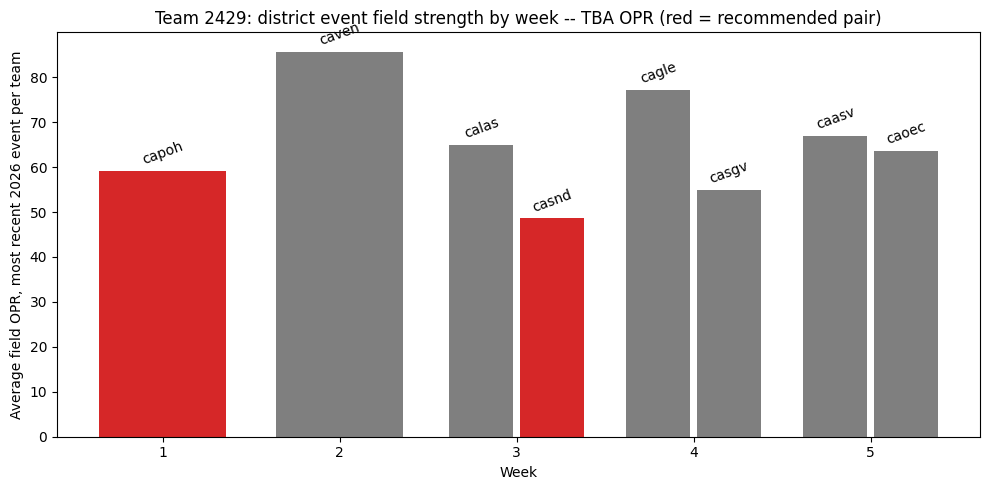

In [41]:
if df_pairs_opr.empty:
    print("Skipping chart -- no recommended OPR pair (see note above).")
else:
    # Highlight the specific recommended events by key, not just their week --
    # a week can have multiple events, and only one of them may be recommended.
    recommended_keys_opr = {best_opr["event_key_a"], best_opr["event_key_b"]}
    plot_field_strength_by_week(
        df_events_opr, "opr_mean", recommended_keys_opr,
        ylabel=f"Average field OPR, most recent {DATA_YEAR} event per team",
        title=f"Team {TEAM}: district event field strength by week -- TBA OPR (red = recommended pair)",
    )

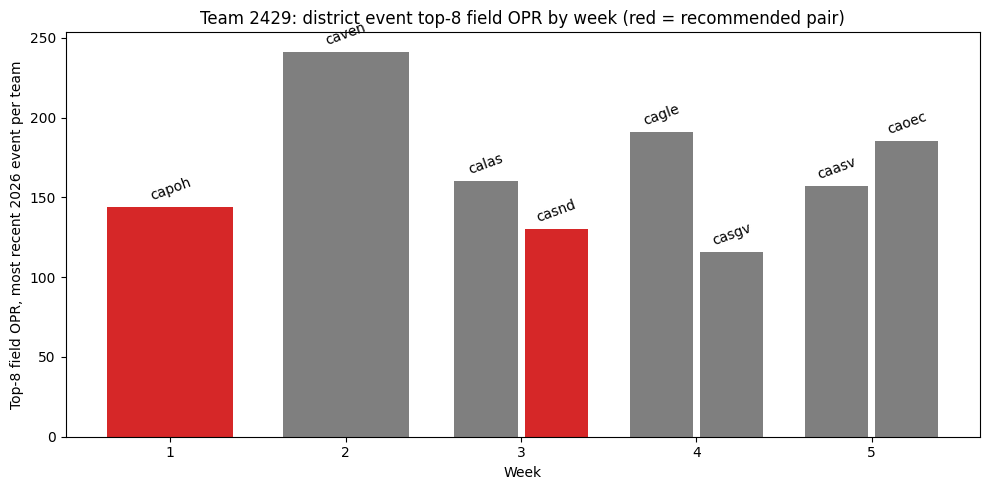

In [42]:
if df_pairs_opr.empty:
    print("Skipping chart -- no recommended OPR pair (see note above).")
else:
    plot_field_strength_by_week(
        df_events_opr, "opr_top8", recommended_keys_opr,
        ylabel=f"Top-8 field OPR, most recent {DATA_YEAR} event per team",
        title=f"Team {TEAM}: district event top-8 field OPR by week (red = recommended pair)",
    )

## Caveats

- If `DATA_YEAR != TARGET_YEAR`, this is a proxy based on an earlier season's
  schedule/rosters -- once FIRST publishes `TARGET_YEAR`'s real calendar and TBA has
  that data, set `DATA_YEAR = TARGET_YEAR` and re-run, and re-check that the assumed
  events/weeks still hold.
- EPA reflects on-field scoring strength only -- it ignores travel distance/cost,
  ranking-point tiebreakers, and how many events actually count toward a team's
  district point ranking.
- The OPR comparison uses each team's **single most recent `DATA_YEAR` event** --
  unlike EPA it isn't a season-long rating, so it's noisier (sensitive to that one
  event's alliance partners/opponents) and teams that didn't play a `DATA_YEAR` event
  are dropped entirely (`num_opr_found` in `df_events_opr` will be lower than
  `num_teams`). Treat the OPR ranking as a sanity check on the EPA-based
  recommendation, not an independent tiebreaker.
- `PREFERRED_EVENT_CODES` only limits which events are *considered* -- it does not
  change who else is in the field at whichever events you actually attend.
- The TBA key you enter is only kept in memory for this kernel session -- it is not
  written into the notebook file, so this file is safe to check in.
